In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [3]:
# 1 Generar datos aleatorios con distribución normal
ruta = "C:/Users/Roland/Documents/GitHub/Proyecto-I-y-II-MatUNADM/DatosClientes/Clientes_Dos_Mil_numeros.csv"
df = pd.read_csv(ruta)
dataframe = df

In [4]:
# 1.1 quitar la variable dependiente "Y"
df = dataframe.drop(['Y'], axis=1) 

In [6]:
df.head()

,Ocupacion,NoPago,TotalMonto,EstadoContrato,Producto,FechaInicioC,FechaAdjudicación,FechaUltimoPago,FechaProyectadaFin,MontoVencido,...,CostoAdmin,Genero,PersonaTipo,dtEstadoContrato,GrupoOrigenVenta,SemanasAdjud,Pagos9,Domicilia_Pago,Email,timetotV
0,47.0,35,302783,6.0,0.0,20150417,20150417,20180221,20200417,5046,...,17468,1.0,0.0,2.0,1.0,0.0,9,1,1,36
1,38.0,38,211366,5.0,0.0,20150220,20150220,20180208,20200220,7044,...,19040,0.0,0.0,2.0,3.0,0.0,9,1,1,40
2,13.0,50,323640,1.0,0.0,20150220,20160115,20190218,20200220,0,...,24485,1.0,0.0,1.0,3.0,47.0,8,1,1,50
3,59.0,60,377036,1.0,0.0,20150417,20150717,20200305,20200417,12566,...,28599,1.0,0.0,1.0,3.0,13.0,9,0,1,61
4,97.0,45,392349,6.0,0.0,20150417,20150417,20181226,20200417,6539,...,22024,0.0,1.0,2.0,3.0,0.0,9,0,1,46


In [ ]:
# 2 Estandarizar los datos
#scaler = StandardScaler()
#df_scaled = scaler.fit_transform(df)

In [7]:
# Calcular la media y la desviación estándar de cada columna
mean_A = np.mean(df, axis=0)  # Media por columna
std_A = np.std(df, axis=0)    # Desviación estándar por columna

In [ ]:
print(std_A)

In [166]:
A_standardized = (df - mean_A)
df_scaled = A_standardized

In [167]:
# media y varianza estandarizada
Smean_A = np.mean(df_scaled, axis=0)  # Media por columna
Sstd_A = np.std(df_scaled, axis=0)    # Desviación estándar por columna

In [168]:
for i, var in enumerate(Smean_A, 1):
    print(f"PC{i}: {abs(var):.2f}%")

PC1: 0.00%
PC2: 0.00%
PC3: 0.00%
PC4: 0.00%
PC5: 0.00%
PC6: 0.00%
PC7: 0.00%
PC8: 0.00%
PC9: 0.00%
PC10: 0.00%
PC11: 0.00%
PC12: 0.00%
PC13: 0.00%
PC14: 0.00%
PC15: 0.00%
PC16: 0.00%
PC17: 0.00%
PC18: 0.00%
PC19: 0.00%
PC20: 0.00%
PC21: 0.00%
PC22: 0.00%
PC23: 0.00%
PC24: 0.00%
PC25: 0.00%
PC26: 0.00%
PC27: 0.00%


In [169]:
print(Sstd_A)

Ocupacion                 33.177049
NoPago                    13.785069
TotalMonto            109700.717935
EstadoContrato             2.668210
Producto                   0.448508
FechaInicioC           14968.618610
FechaAdjudicación      15502.424500
FechaUltimoPago        14161.690450
FechaProyectadaFin     14968.618610
MontoVencido           12001.921751
Mensualidad             1771.086617
Ingresos               10303.524473
Legal                      0.438634
EdadActual                11.366112
AZULEstatus                0.436422
AdjudicaReal               0.888345
PagosPuntuales            14.950317
CostoAdmin              6839.984189
Genero                     0.474546
PersonaTipo                0.288319
dtEstadoContrato           0.851135
GrupoOrigenVenta           1.402782
SemanasAdjud              29.483604
Pagos9                     1.024456
Domicilia_Pago             0.374310
Email                      0.136525
timetotV                  13.375397
dtype: float64


In [170]:
# 1️⃣ Calcular la varianza de cada variable (columna)
varianza_columnas = df_scaled.var()

In [ ]:
print(varianza_columnas)

In [171]:
# 3 Aplicar PCA con todas las componentes
pca = PCA(n_components=len(df.columns))
pca.fit(df_scaled)

PCA(n_components=27)

In [172]:
# 3️⃣ Obtener la matriz de cargas (loadings)
loadings = pd.DataFrame(pca.components_.T, 
                        columns=[f'PC{i+1}' for i in range(len(df.columns))], 
                        index=df.columns)

In [ ]:
print(loadings)

In [173]:
# 5️⃣ Seleccionar las 2 PCs más importantes
top_pcs = ['PC1', 'PC2','PC3','PC4','PC5','PC6','PC7','PC8','PC9','PC10','PC11','PC12','PC13']  # Puedes cambiar si la varianza acumulada lo indica

In [174]:
# 6️⃣ Tomar el valor absoluto y sumar la influencia en PC1 y PC2..PC13
Caracteristicas_principales = loadings[top_pcs].abs().sum(axis=1).sort_values(ascending=False)

In [175]:
print(Caracteristicas_principales)

FechaUltimoPago       2.092550
CostoAdmin            1.723639
FechaAdjudicación     1.697947
FechaInicioC          1.535085
FechaProyectadaFin    1.535085
MontoVencido          1.511652
Ingresos              1.257913
TotalMonto            1.246641
SemanasAdjud          1.076867
EdadActual            1.056728
Mensualidad           1.047182
Ocupacion             1.028358
EstadoContrato        1.020480
timetotV              0.642883
PagosPuntuales        0.640613
NoPago                0.616070
dtEstadoContrato      0.308470
AdjudicaReal          0.063580
Pagos9                0.041520
GrupoOrigenVenta      0.032650
Producto              0.024746
PersonaTipo           0.021630
AZULEstatus           0.019604
Domicilia_Pago        0.011625
Legal                 0.008865
Genero                0.008441
Email                 0.001613
dtype: float64


In [176]:
# 7️⃣ Seleccionar las 2 variables más influyentes
selected_variables = Caracteristicas_principales.index[:12]
print("\n✅ Variables seleccionadas para la Regresión Logística:", selected_variables.tolist())


✅ Variables seleccionadas para la Regresión Logística: ['FechaUltimoPago', 'CostoAdmin', 'FechaAdjudicación', 'FechaInicioC', 'FechaProyectadaFin', 'MontoVencido', 'Ingresos', 'TotalMonto', 'SemanasAdjud', 'EdadActual', 'Mensualidad', 'Ocupacion']


In [177]:
print(selected_variables)

Index(['FechaUltimoPago', 'CostoAdmin', 'FechaAdjudicación', 'FechaInicioC',
       'FechaProyectadaFin', 'MontoVencido', 'Ingresos', 'TotalMonto',
       'SemanasAdjud', 'EdadActual', 'Mensualidad', 'Ocupacion'],
      dtype='object')


In [178]:
# 4️⃣ Obtener la varianza explicada y ordenar de mayor a menor
explained_variance = pca.explained_variance_ratio_ * 100  # En porcentaje
sorted_indices = np.argsort(explained_variance)[::-1]  # Indices ordenados de mayor a menor

sorted_explained_variance = explained_variance[sorted_indices]  # Ordenamos valores
sorted_components = [f'PC{i+1}' for i in sorted_indices]  # Etiquetas ordenadas

In [179]:
# 5️⃣ Calcular la varianza acumulada
cumulative_variance = np.cumsum(sorted_explained_variance)  # Varianza acumulada

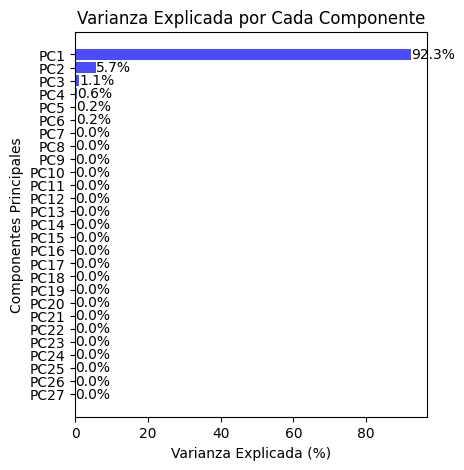

In [181]:
# 6️⃣ Gráfica de varianza explicada (Vertical y Ordenada)
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
bars = plt.barh(range(len(df.columns), 0, -1), sorted_explained_variance, color='blue', alpha=0.7)
plt.ylabel('Componentes Principales')
plt.xlabel('Varianza Explicada (%)')
plt.title('Varianza Explicada por Cada Componente')
plt.yticks(range(len(df.columns), 0, -1), labels=sorted_components)

# Etiquetas en cada barra con el porcentaje de varianza explicada
for bar, var in zip(bars, sorted_explained_variance):
    xval = bar.get_width()
    plt.text(xval, bar.get_y() + bar.get_height()/2, f'{var:.1f}%', ha='left', va='center', fontsize=10)


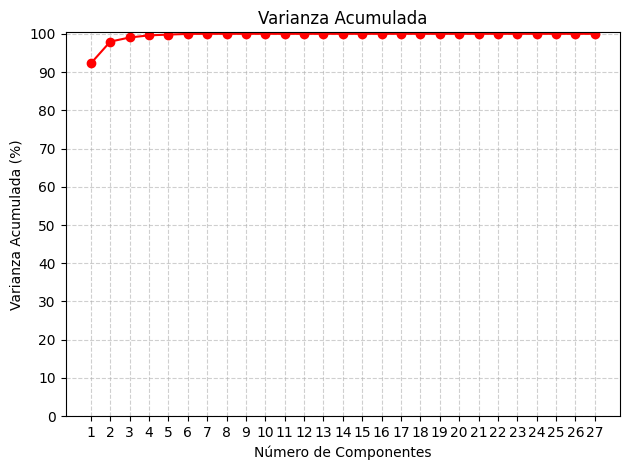

In [182]:
# 7️⃣ Gráfica de varianza acumulada
# 📌 Gráfica de varianza acumulada (Doble de ancha)
plt.subplot(1, 3, (1, 3))  # Ocupará 2/3 del espacio
plt.plot(range(1, len(df.columns) + 1), cumulative_variance, marker='o', linestyle='-', color='red')
plt.xlabel('Número de Componentes')
plt.ylabel('Varianza Acumulada (%)')
plt.title('Varianza Acumulada')
plt.xticks(range(1, len(df.columns) + 1))
plt.yticks(range(0, 110, 10))  # Escalado de 10 en 10 hasta 100%
plt.grid(True, linestyle='--', alpha=0.6)

# Mostrar las dos gráficas
plt.tight_layout()
plt.show()

In [183]:
# 7️⃣ Mostramos los resultados numéricos
print("\nMatriz de cargas (qué tan importante es cada variable en cada componente):")
print(loadings)

print("\nVarianza explicada por cada componente (%):")
for i, var in enumerate(explained_variance, 1):
    print(f"PC{i}: {var:.2f}%")

print("\nVarianza acumulada (Varianza explicada Acumulada):")
for i, var in enumerate(cumulative_variance, 1):
    print(f"PC{i}: {var:.2f}%")


Matriz de cargas (qué tan importante es cada variable en cada componente):
                             PC1           PC2           PC3           PC4  \
Ocupacion           2.735646e-06  1.133884e-06  1.079772e-04 -1.979657e-05   
NoPago              8.267567e-05 -1.139025e-04 -4.278285e-04  8.722387e-04   
TotalMonto          9.930701e-01  4.890585e-02  2.749350e-02 -6.083691e-02   
EstadoContrato      5.643325e-07  8.406542e-06  2.472063e-05 -5.693998e-05   
Producto           -7.164993e-07  6.915761e-06  4.317127e-06 -3.540061e-06   
FechaInicioC       -3.918995e-02  5.084878e-01  1.743800e-01 -1.916267e-01   
FechaAdjudicación  -3.436851e-02  5.213864e-01  1.082806e-01 -2.121183e-02   
FechaUltimoPago     3.243439e-02  4.217647e-01 -2.908411e-01  7.418009e-01   
FechaProyectadaFin -3.918995e-02  5.084878e-01  1.743800e-01 -1.916267e-01   
MontoVencido        7.375079e-03 -1.489504e-01  8.911285e-01  4.279309e-01   
Mensualidad         1.598178e-02  5.579146e-04  5.287251e-04 -5.37

In [188]:
df_selected = df[selected_variables]

In [189]:
df_selected.head()

,FechaUltimoPago,CostoAdmin,FechaAdjudicación,FechaInicioC,FechaProyectadaFin,MontoVencido,Ingresos,TotalMonto,SemanasAdjud,EdadActual,Mensualidad,Ocupacion
0,20180221,17468,20150417,20150417,20200417,5046,19125,302783,0.0,24,5046,47.0
1,20180208,19040,20150220,20150220,20200220,7044,22327,211366,0.0,41,3522,38.0
2,20190218,24485,20160115,20150220,20200220,0,34514,323640,47.0,25,5394,13.0
3,20200305,28599,20150717,20150417,20200417,12566,35754,377036,13.0,41,6283,59.0
4,20181226,22024,20150417,20150417,20200417,6539,40430,392349,0.0,56,6539,97.0


In [192]:
# 1️⃣ Seleccionar la última columna de df
ultima_columna = dataframe.iloc[:, -1]  # Selecciona la última columna

In [193]:
ultima_columna.head()

0    1
1    1
2    1
3    1
4    1
Name: Y, dtype: int64

In [194]:

# 2️⃣ Agregar la última columna a df_selected
df_selected = pd.concat([df_selected, ultima_columna], axis=1)

In [195]:
# 8️⃣ Guardar solo estas variables en un CSV

df_selected.to_csv("C:/Users/Roland/Documents/GitHub/Proyecto-I-y-II-MatUNADM/DatosClientes/variables_seleccionadas.csv", index=False)
print("\n📂 Archivo 'variables_seleccionadas.csv' guardado con éxito.")


📂 Archivo 'variables_seleccionadas.csv' guardado con éxito.
